# Statistics analysis

This notebook averages repeated executions only when all recorded grid-search parameters match. It then compares the best averaged configuration for each implementation and dataset type, and keeps the scaling comparison separate from the grid-search comparison.

In [210]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

CSV_PATTERN = "hashjoin_*.csv"
RESULTS_CANDIDATES = [Path("src/results"), Path("results"), Path("../results")]
OLD_RESULTS_CANDIDATES = [Path("src/old_results"), Path("old_results"), Path("../old_results")]

GRID_TO_RESULT_COLUMNS = {
    "N_VALUES": ["nr", "ns"],
    "P_VALUES": ["p", "num_partitions", "partition_count"],
    "SEED_VALUES": ["seed"],
    "MAX_KEY_VALUES": ["max_key"],
    "DATASET_TYPE_VALUES": ["dataset_type"],
    "NODE_VALUES": ["mpi_nodes"],
    "MPI_PROCESS_VALUES": ["mpi_processes", "mpi_world_size", "mpi_active_ranks"],
    "MPI_PARTITION_STRATEGY_VALUES": ["mpi_partition_strategy"],
    "PARTITION_THREAD_VALUES": ["partition_threads"],
    "JOIN_THREAD_VALUES": ["join_threads"],
    "PARTITION_SCHEDULE_VALUES": ["partition_schedule"],
    "JOIN_SCHEDULE_VALUES": ["join_schedule"],
    "PARTITION_CHUNK_VALUES": ["partition_chunk"],
    "JOIN_CHUNK_VALUES": ["join_chunk"],
    "PARTITION_BLOCK_SIZE_VALUES": ["partition_block_size"],
    "PARTITION_TASK_GRAIN_VALUES": ["partition_task_grain"],
    "JOIN_TASK_GRAIN_VALUES": ["join_task_grain"],
    "OFFSET_TASK_GRAIN_VALUES": ["offset_task_grain"],
}

NUMERIC_COLUMNS = [
    "checksum1", "checksum2", "join_count", "join_threads", "join_throughput",
    "join_time", "max_key", "nr", "ns", "p", "num_partitions",
    "mpi_nodes", "mpi_processes", "mpi_world_size", "mpi_active_ranks",
    "partition_threads", "partition_throughput", "partition_time", "time_sec",
    "tot_sec", "total_throughput", "partition_chunk", "join_chunk",
    "partition_block_size", "partition_task_grain", "join_task_grain",
    "offset_task_grain", "redistribution_time", "redistribution_throughput",
    "skew_fraction", "skew_partition_fraction", "seed",
]

EXEC_TYPE_ORDER = ["seq", "omp", "mpi", "hybrid", "omp_loop", "omp_loop_wb", "omp_task", "omp_task_wb", "omp_taskloop", "omp_taskloop_wb"]


def first_existing_dir(candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def find_csv_files(candidates, pattern):
    for candidate_dir in candidates:
        candidate_files = sorted(candidate_dir.glob(pattern))
        if candidate_files:
            return candidate_dir, candidate_files
    return None, []


def normalize_frame(frame):
    frame = frame.copy()
    if "tot_sec" not in frame.columns and "time_sec" in frame.columns:
        frame["tot_sec"] = frame["time_sec"]
    if "time_sec" not in frame.columns and "tot_sec" in frame.columns:
        frame["time_sec"] = frame["tot_sec"]
    if "dataset_type" not in frame.columns:
        frame["dataset_type"] = "uniform"

    for col in NUMERIC_COLUMNS:
        if col in frame.columns:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")

    if {"nr", "ns", "tot_sec"}.issubset(frame.columns):
        fallback_total_throughput = (frame["nr"] + frame["ns"]) / frame["tot_sec"].where(frame["tot_sec"] > 0)
        if "total_throughput" not in frame.columns:
            frame["total_throughput"] = fallback_total_throughput
        else:
            frame["total_throughput"] = frame["total_throughput"].fillna(fallback_total_throughput)

    return frame


RESULTS_DIR, csv_files = find_csv_files(RESULTS_CANDIDATES, CSV_PATTERN)
if not csv_files or RESULTS_DIR is None:
    searched = ", ".join(str(p) for p in RESULTS_CANDIDATES)
    raise FileNotFoundError(f"No CSV files found with pattern {CSV_PATTERN} in: {searched}")

frames = []
for csv_path in csv_files:
    current_df = pd.read_csv(csv_path)
    current_df["exec_type"] = csv_path.stem.replace("hashjoin_", "", 1)
    frames.append(normalize_frame(current_df))

df = pd.concat(frames, ignore_index=True, sort=False)

exec_type_names = sorted(df["exec_type"].dropna().unique(), key=lambda x: (EXEC_TYPE_ORDER.index(x) if x in EXEC_TYPE_ORDER else len(EXEC_TYPE_ORDER), x))
EXEC_TYPE_COLORS = {
    "seq": "#EB9A21",    # Orange
    "omp": "#1976D2",    # Blue 700
    "mpi": "#A82D2D",    # Red
    "hybrid": "#388E3C", # Green 700
}
fallback_exec_type_palette = ["#3F51B5", "#009688", "#F44336", "#9C27B0", "#8BC34A", "#03A9F4", "#795548"]
color_map = {
    exec_type: EXEC_TYPE_COLORS.get(exec_type, fallback_exec_type_palette[idx % len(fallback_exec_type_palette)])
    for idx, exec_type in enumerate(exec_type_names)
}

DATASET_TYPE_ORDER = ["uniform", "skewed_90_5", "skewed_90_1"]
DATASET_TYPE_COLORS = {
    "uniform": "#1f77b4",
    "skewed_90_5": "#ff7f0e",
    "skewed_90_1": "#d62728",
}


def apply_tone(base_color, tone_strength):
    strength = float(max(0.0, min(1.0, tone_strength)))
    base_rgb = mcolors.to_rgb(base_color)
    toned_rgb = tuple(1.0 - strength * (1.0 - channel) for channel in base_rgb)
    return mcolors.to_hex(toned_rgb)


def build_tone_strength_map(values, min_strength=0.45, max_strength=1.0):
    ordered = sorted(values)
    if not ordered:
        return {}
    if len(ordered) == 1:
        return {ordered[0]: float(max_strength)}
    span = float(max_strength) - float(min_strength)
    return {value: float(min_strength) + span * idx / (len(ordered) - 1) for idx, value in enumerate(ordered)}


def ordered_values(values, preferred=None):
    clean = [value for value in pd.Series(values).dropna().unique()]
    if preferred is None:
        return sorted(clean)
    return sorted(clean, key=lambda x: (preferred.index(x) if x in preferred else len(preferred), str(x)))


def fmt_num(value):
    if pd.isna(value):
        return "NA"
    value_float = float(value)
    return str(int(value_float)) if value_float.is_integer() else f"{value_float:g}"


def problem_label(row_or_tuple):
    if isinstance(row_or_tuple, tuple):
        nr, ns, max_key = row_or_tuple
    else:
        nr, ns, max_key = row_or_tuple["nr"], row_or_tuple["ns"], row_or_tuple["max_key"]
    return f"nr={fmt_num(nr)}, ns={fmt_num(ns)}, max_key={fmt_num(max_key)}"


def resolve_img_dir():
    candidates = [Path("src/img"), Path("img"), Path("../src/img"), Path("../img")]
    for candidate in candidates:
        if candidate.parent.exists() or candidate.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate
    fallback = Path("img")
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback


IMG_DIR = resolve_img_dir()
PLOT_SAVE_COUNTER = 0


def slugify(value):
    cleaned = re.sub(r"[^A-Za-z0-9._-]+", "_", str(value)).strip("_")
    return (cleaned or "plot")[:180]


def save_figure(fig, name_prefix):
    global PLOT_SAVE_COUNTER
    PLOT_SAVE_COUNTER += 1
    filename = f"{PLOT_SAVE_COUNTER:03d}_{slugify(name_prefix)}.png"
    output_path = IMG_DIR / filename
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"[saved] {output_path}")


def show_and_save(fig, name_prefix):
    save_figure(fig, name_prefix)
    plt.show()
    plt.close(fig)


print(f"[Loaded {df.shape[0]} runs from {RESULTS_DIR}]\n")
print("Files:")
for csv_path in csv_files:
    print(f"  - {csv_path.name}")
print("\nDistinct values:")
print(f"  exec_type: {exec_type_names}")
print(f"  dataset_type: {ordered_values(df['dataset_type'])}")
print(f"  max_key: {ordered_values(df['max_key'])}")
print(f"  partition_threads: {ordered_values(df['partition_threads']) if 'partition_threads' in df.columns else []}")
print(f"  join_threads: {ordered_values(df['join_threads']) if 'join_threads' in df.columns else []}")
print(f"  image_output_dir: {IMG_DIR}")


[Loaded 435 runs from results]

Files:
  - hashjoin_hybrid.csv
  - hashjoin_mpi.csv
  - hashjoin_omp.csv
  - hashjoin_seq.csv

Distinct values:
  exec_type: ['seq', 'omp', 'mpi', 'hybrid']
  dataset_type: ['skewed_90_1', 'skewed_90_5', 'uniform']
  max_key: [np.int64(1000000)]
  partition_threads: [np.float64(1.0), np.float64(16.0), np.float64(32.0)]
  join_threads: [np.float64(1.0), np.float64(16.0), np.float64(32.0)]
  image_output_dir: img


# Checksum validation

In [211]:
checksum_group_cols = [col for col in ["nr", "ns", "max_key", "dataset_type"] if col in df.columns]
summary_rows = []

for key_values, subdf in df.groupby(checksum_group_cols, dropna=False):
    if not isinstance(key_values, tuple):
        key_values = (key_values,)
    row = dict(zip(checksum_group_cols, key_values))
    checksum_pairs = subdf[["checksum1", "checksum2"]].drop_duplicates() if {"checksum1", "checksum2"}.issubset(subdf.columns) else pd.DataFrame()
    row.update({
        "n_distinct_checksum_pairs": len(checksum_pairs),
        "is_valid": len(checksum_pairs) == 1,
        "exec_types": ", ".join(ordered_values(subdf["exec_type"], EXEC_TYPE_ORDER)),
    })
    summary_rows.append(row)

checksum_validation_df = pd.DataFrame(summary_rows).sort_values(checksum_group_cols).reset_index(drop=True)
valid_groups = int(checksum_validation_df["is_valid"].sum()) if not checksum_validation_df.empty else 0
print(f"[OK groups: {valid_groups}/{len(checksum_validation_df)}]")
checksum_validation_df


[OK groups: 3/3]


,nr,ns,max_key,dataset_type,n_distinct_checksum_pairs,is_valid,exec_types
0,50000000,50000000,1000000,skewed_90_1,1,True,"seq, omp, mpi, hybrid"
1,50000000,50000000,1000000,skewed_90_5,1,True,"seq, omp, mpi, hybrid"
2,50000000,50000000,1000000,uniform,1,True,"seq, omp, mpi, hybrid"


# Average by Grid Parameters

In [212]:
recorded_grid_columns = []
missing_grid_parameters = []
for grid_name, candidate_columns in GRID_TO_RESULT_COLUMNS.items():
    present_columns = [col for col in candidate_columns if col in df.columns]
    if present_columns:
        for col in present_columns:
            if col not in recorded_grid_columns:
                recorded_grid_columns.append(col)
    else:
        missing_grid_parameters.append(grid_name)

avg_group_columns = ["exec_type"] + [col for col in recorded_grid_columns if col != "exec_type"]
avg_group_columns = [col for col in avg_group_columns if col in df.columns]

avg_columns = [
    col for col in df.columns
    if col not in avg_group_columns and pd.api.types.is_numeric_dtype(df[col])
]

stable_avg_df = (
    df.groupby(avg_group_columns, as_index=False, dropna=False)
    .agg(**{col: (col, "mean") for col in avg_columns}, n_runs=("tot_sec", "size"))
    .sort_values(avg_group_columns)
    .reset_index(drop=True)
)

# Runtime not accounted for by the measured partition and join phases.
# For MPI/hybrid runs this includes redistribution, reductions, barriers, and other synchronization overhead.
if {"tot_sec", "partition_time", "join_time"}.issubset(stable_avg_df.columns):
    stable_avg_df["redistribution_time"] = (
        stable_avg_df["tot_sec"] - stable_avg_df["partition_time"] - stable_avg_df["join_time"]
    ).clip(lower=0)
    if {"nr", "ns"}.issubset(stable_avg_df.columns):
        stable_avg_df["redistribution_throughput"] = np.where(
            stable_avg_df["redistribution_time"] > 0,
            (stable_avg_df["nr"] + stable_avg_df["ns"]) / stable_avg_df["redistribution_time"],
            0.0,
        )

print(f"recorded_grid_columns={recorded_grid_columns}")
if missing_grid_parameters:
    print(f"[warning] grid parameters absent from CSV and not usable as average keys: {missing_grid_parameters}")
print(f"non_averaged={df.shape}")
print(f"averaged={stable_avg_df.shape}")
display(stable_avg_df.head(10))


recorded_grid_columns=['nr', 'ns', 'max_key', 'dataset_type', 'mpi_nodes', 'mpi_processes', 'mpi_world_size', 'mpi_active_ranks', 'mpi_partition_strategy', 'partition_threads', 'join_threads', 'partition_schedule', 'join_schedule', 'partition_chunk', 'join_chunk', 'partition_block_size', 'partition_task_grain', 'join_task_grain', 'offset_task_grain']
[warning] grid parameters absent from CSV and not usable as average keys: ['P_VALUES', 'SEED_VALUES']
non_averaged=(435, 34)
averaged=(87, 36)


,exec_type,nr,ns,max_key,dataset_type,mpi_nodes,mpi_processes,mpi_world_size,mpi_active_ranks,mpi_partition_strategy,...,partition_time,time_sec,total_throughput,verified,tot_sec,skew_fraction,skew_partition_fraction,n_runs,redistribution_time,redistribution_throughput
0,hybrid,50000000,50000000,1000000,skewed_90_1,1,1,1.0,1.0,block,...,0.327575,8.007409,1.248994e+07,0.0,8.007409,NaN,NaN,5,6.618954,1.510813e+07
1,hybrid,50000000,50000000,1000000,skewed_90_1,1,1,1.0,1.0,cyclic,...,0.327521,6.333556,1.578954e+07,0.0,6.333556,NaN,NaN,5,4.941726,2.023584e+07
2,hybrid,50000000,50000000,1000000,skewed_90_1,1,4,4.0,4.0,block,...,0.332913,3.496662,2.860360e+07,0.0,3.496662,NaN,NaN,5,2.069414,4.832285e+07
3,hybrid,50000000,50000000,1000000,skewed_90_1,1,4,4.0,4.0,cyclic,...,0.188388,3.484633,2.869803e+07,0.0,3.484633,NaN,NaN,5,1.392121,7.183282e+07
4,hybrid,50000000,50000000,1000000,skewed_90_1,1,8,8.0,8.0,block,...,0.364928,2.686182,3.723033e+07,0.0,2.686182,NaN,NaN,5,1.234938,8.097573e+07
5,hybrid,50000000,50000000,1000000,skewed_90_1,1,8,8.0,8.0,cyclic,...,0.273175,3.022476,3.309195e+07,0.0,3.022476,NaN,NaN,5,0.771718,1.295810e+08
6,hybrid,50000000,50000000,1000000,skewed_90_1,4,4,4.0,4.0,block,...,0.304550,3.655778,2.735426e+07,0.0,3.655778,NaN,NaN,5,2.279555,4.386821e+07
7,hybrid,50000000,50000000,1000000,skewed_90_1,4,4,4.0,4.0,cyclic,...,0.109692,2.105526,4.750384e+07,0.0,2.105526,NaN,NaN,5,1.418338,7.050508e+07
8,hybrid,50000000,50000000,1000000,skewed_90_1,4,8,8.0,8.0,block,...,0.282826,3.688265,2.711344e+07,0.0,3.688265,NaN,NaN,5,1.470325,6.801217e+07
9,hybrid,50000000,50000000,1000000,skewed_90_1,4,8,8.0,8.0,cyclic,...,0.101054,2.444031,4.092434e+07,0.0,2.444031,NaN,NaN,5,0.982100,1.018226e+08


# Best Averaged Records

In [213]:
problem_columns = [col for col in ["nr", "ns", "max_key"] if col in stable_avg_df.columns]
best_group_columns = problem_columns + ["dataset_type", "exec_type"]

eligible = stable_avg_df.dropna(subset=["tot_sec"]).copy()
if eligible.empty:
    raise ValueError("No averaged rows with tot_sec available")

best_indices = eligible.groupby(best_group_columns, dropna=False)["tot_sec"].idxmin()
selected_best_df = (
    eligible.loc[best_indices]
    .sort_values(best_group_columns)
    .reset_index(drop=True)
)

best_config_columns = [
    col for col in best_group_columns + [
        "n_runs", "tot_sec", "partition_time", "join_time", "redistribution_time", "redistribution_throughput", "total_throughput",
        "partition_threads", "join_threads", "partition_schedule", "join_schedule",
        "partition_chunk", "join_chunk", "partition_block_size",
        "partition_task_grain", "join_task_grain", "offset_task_grain",
        "mpi_nodes", "mpi_processes", "mpi_world_size", "mpi_active_ranks",
        "mpi_partition_strategy",
    ]
    if col in selected_best_df.columns
]

print(f"selected_best_records={selected_best_df.shape}")
selected_best_df[best_config_columns]


selected_best_records=(12, 36)


,nr,ns,max_key,dataset_type,exec_type,n_runs,tot_sec,partition_time,join_time,redistribution_time,...,join_chunk,partition_block_size,partition_task_grain,join_task_grain,offset_task_grain,mpi_nodes,mpi_processes,mpi_world_size,mpi_active_ranks,mpi_partition_strategy
0,50000000,50000000,1000000,skewed_90_1,hybrid,5,1.555474,0.105230,0.569112,0.881133,...,4.0,32768.0,NaN,NaN,NaN,8,8,8.0,8.0,cyclic
1,50000000,50000000,1000000,skewed_90_1,mpi,5,1.838680,0.259173,0.824089,0.755418,...,NaN,NaN,NaN,NaN,NaN,1,8,8.0,8.0,cyclic
2,50000000,50000000,1000000,skewed_90_1,omp,5,1.664108,0.334625,1.326118,0.003365,...,4.0,32768.0,NaN,NaN,NaN,1,1,NaN,NaN,block
3,50000000,50000000,1000000,skewed_90_1,seq,5,3.092431,0.795621,2.294389,0.002422,...,0.0,32768.0,1.0,1.0,1.0,1,1,NaN,NaN,block
4,50000000,50000000,1000000,skewed_90_5,hybrid,5,1.018777,0.054706,0.154998,0.809073,...,4.0,32768.0,NaN,NaN,NaN,8,8,8.0,8.0,cyclic
5,50000000,50000000,1000000,skewed_90_5,mpi,5,1.101309,0.123905,0.283952,0.693451,...,NaN,NaN,NaN,NaN,NaN,1,8,8.0,8.0,cyclic
6,50000000,50000000,1000000,skewed_90_5,omp,5,0.768023,0.353084,0.411525,0.003414,...,4.0,32768.0,NaN,NaN,NaN,1,1,NaN,NaN,block
7,50000000,50000000,1000000,skewed_90_5,seq,5,2.788284,1.125336,1.660437,0.002511,...,0.0,32768.0,1.0,1.0,1.0,1,1,NaN,NaN,block
8,50000000,50000000,1000000,uniform,hybrid,5,0.821780,0.051907,0.035048,0.734825,...,4.0,32768.0,NaN,NaN,NaN,8,8,8.0,8.0,cyclic
9,50000000,50000000,1000000,uniform,mpi,5,1.022461,0.095336,0.245807,0.681318,...,NaN,NaN,NaN,NaN,NaN,8,8,8.0,8.0,cyclic


# Selected-Record Comparisons

[saved] img/001_selected_best_tot_sec_50000000_50000000_1000000.png


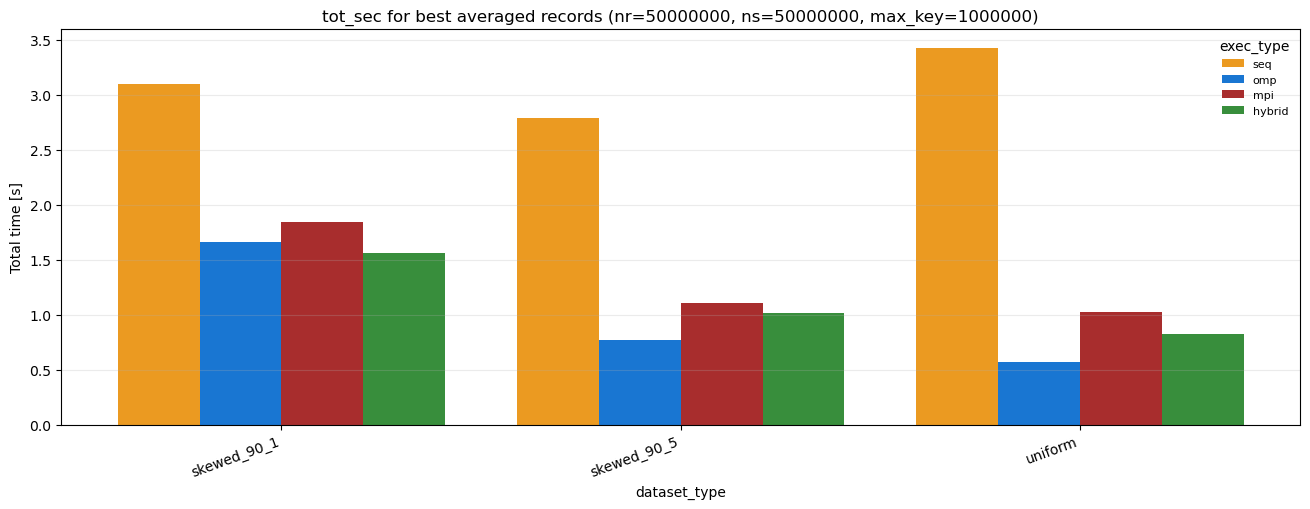

[saved] img/002_selected_best_partition_time_50000000_50000000_1000000.png


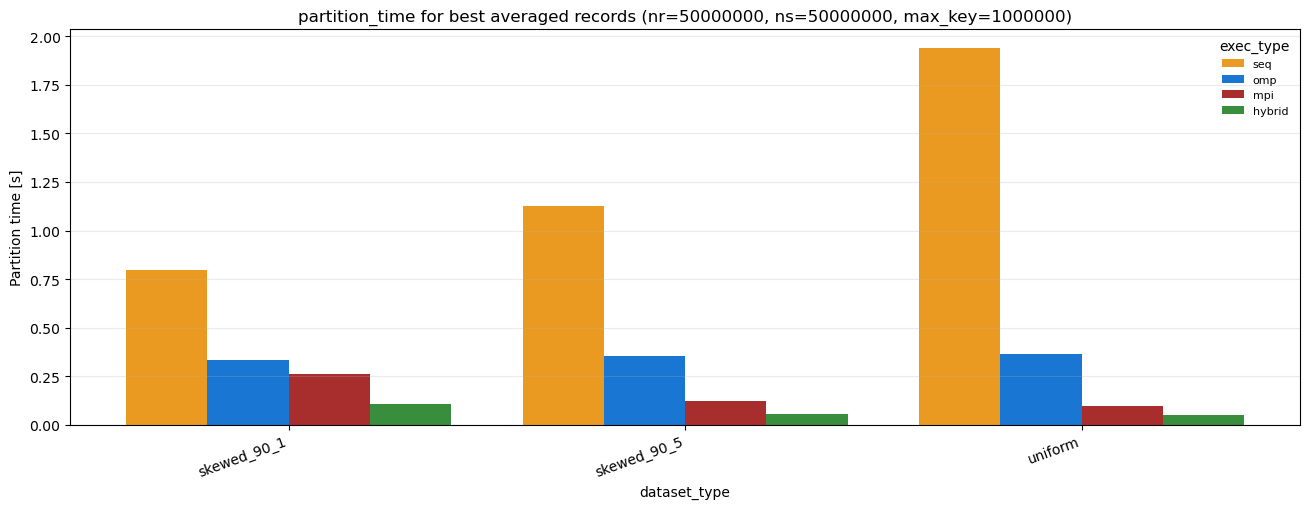

[saved] img/003_selected_best_join_time_50000000_50000000_1000000.png


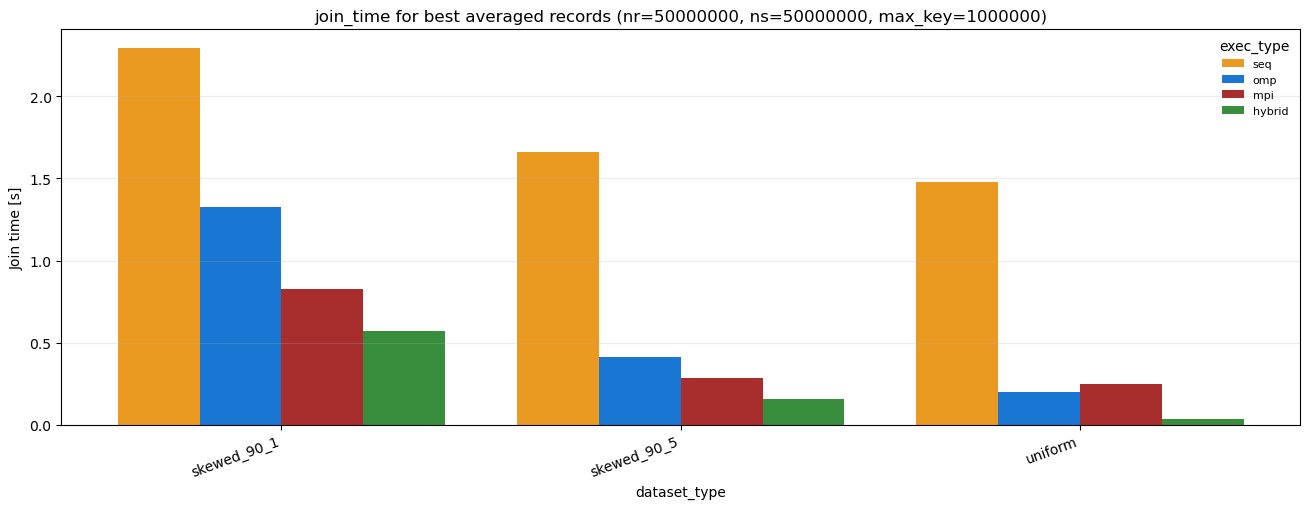

[saved] img/004_selected_best_redistribution_time_50000000_50000000_1000000.png


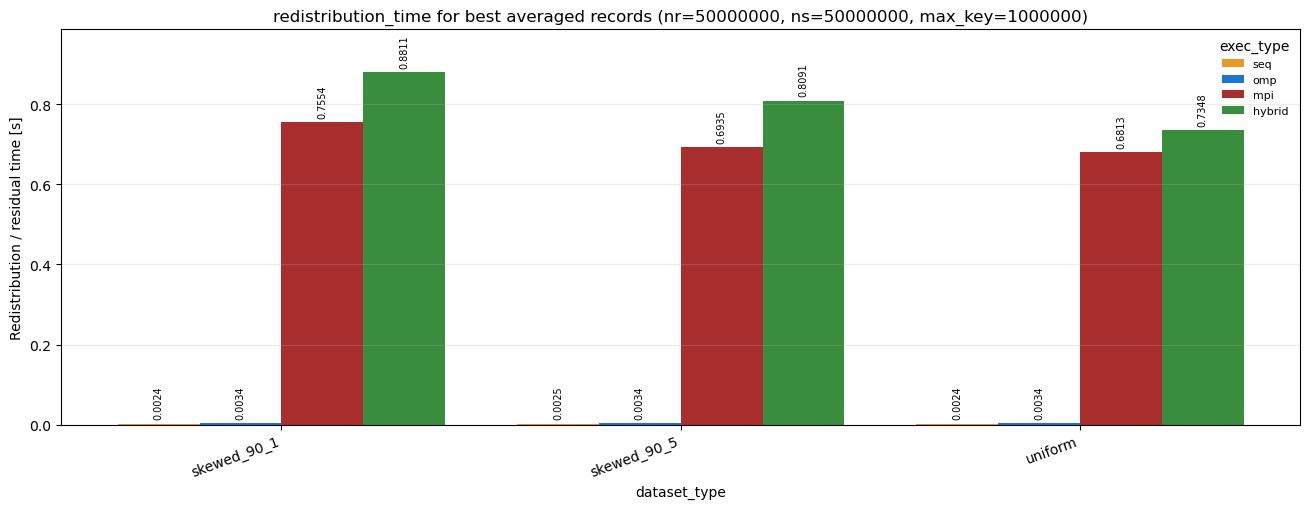

In [214]:
def plot_selected_metric(metric_df, metric_col, ylabel, title_prefix, hline=None):
    required = set(problem_columns + ["dataset_type", "exec_type", metric_col])
    missing = sorted(required - set(metric_df.columns))
    if missing:
        print(f"Skipping {metric_col}: missing columns {missing}")
        return

    plot_df = metric_df.dropna(subset=[metric_col]).copy()
    if plot_df.empty:
        print(f"Skipping {metric_col}: no valid values")
        return

    for problem_key, subdf in plot_df.groupby(problem_columns, dropna=False):
        if not isinstance(problem_key, tuple):
            problem_key = (problem_key,)
        dataset_types = ordered_values(subdf["dataset_type"])
        exec_types = ordered_values(subdf["exec_type"], EXEC_TYPE_ORDER)
        if not dataset_types or not exec_types:
            continue

        x_positions = np.arange(len(dataset_types))
        bar_width = 0.82 / max(len(exec_types), 1)
        fig, ax = plt.subplots(figsize=(max(8.8, 1.1 * len(dataset_types) * len(exec_types)), 5.2))

        for idx, exec_type in enumerate(exec_types):
            sub = subdf[subdf["exec_type"] == exec_type].set_index("dataset_type")[metric_col].to_dict()
            heights = [float(sub.get(dataset_type, np.nan)) for dataset_type in dataset_types]
            offsets = x_positions + (idx - (len(exec_types) - 1) / 2.0) * bar_width
            bars = ax.bar(offsets, heights, width=bar_width, label=exec_type, color=color_map.get(exec_type, "tab:gray"))
            if metric_col == "redistribution_time":
                ax.bar_label(
                    bars,
                    labels=[f"{value:.4f}" if np.isfinite(value) else "" for value in heights],
                    padding=3,
                    fontsize=7,
                    rotation=90,
                )

        if hline is not None:
            ax.axhline(float(hline), color="black", linestyle=":", linewidth=1.2)

        ax.set_xticks(x_positions)
        ax.set_xticklabels(dataset_types, rotation=20, ha="right")
        ax.set_xlabel("dataset_type")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{title_prefix} for best averaged records ({problem_label(problem_key)})")
        ax.grid(axis="y", alpha=0.25)
        if metric_col == "redistribution_time":
            ax.margins(y=0.12)
        ax.legend(title="exec_type", fontsize=8, frameon=False)
        fig.tight_layout()
        show_and_save(fig, f"selected_best_{title_prefix}_{'_'.join(fmt_num(v) for v in problem_key)}")


selected_metric_specs = [
    ("tot_sec", "Total time [s]", "tot_sec"),
    ("partition_time", "Partition time [s]", "partition_time"),
    ("join_time", "Join time [s]", "join_time"),
    ("redistribution_time", "Redistribution / residual time [s]", "redistribution_time"),
]

for metric_col, ylabel, title_prefix in selected_metric_specs:
    plot_selected_metric(selected_best_df, metric_col, ylabel, title_prefix)


# Speedup and Phase Breakdown

[saved] img/005_selected_best_Speedup_vs_sequential_version_50000000_50000000_1000000.png


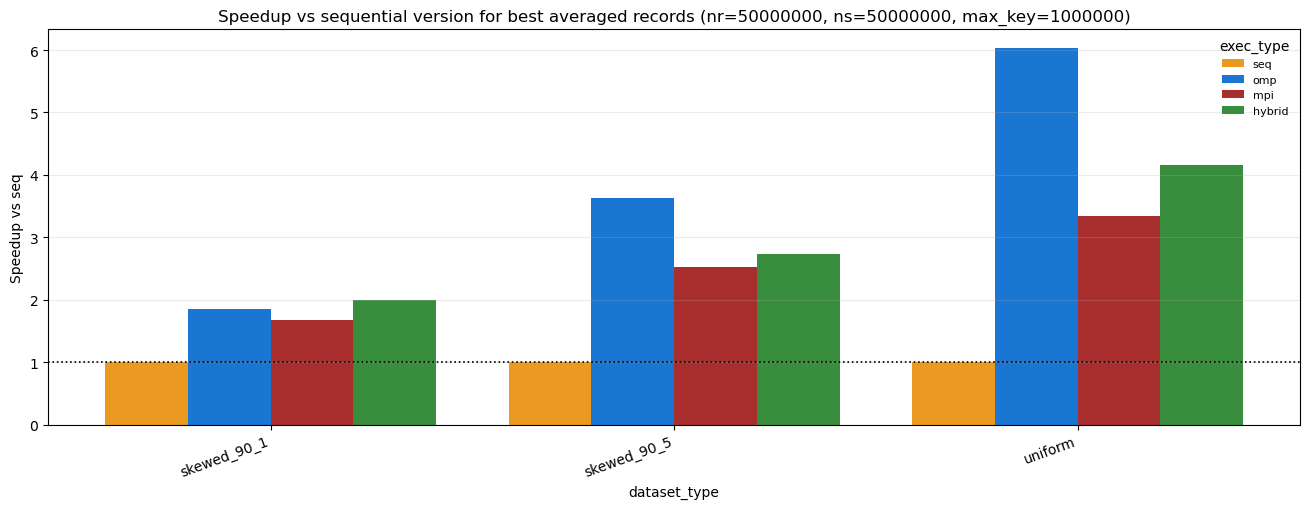

,nr,ns,max_key,dataset_type,exec_type,tot_sec,seq_tot_sec,speedup_vs_seq
0,50000000,50000000,1000000,skewed_90_1,hybrid,1.555474,3.092431,1.988095
1,50000000,50000000,1000000,skewed_90_1,mpi,1.838680,3.092431,1.681876
2,50000000,50000000,1000000,skewed_90_1,omp,1.664108,3.092431,1.858311
3,50000000,50000000,1000000,skewed_90_1,seq,3.092431,3.092431,1.000000
4,50000000,50000000,1000000,skewed_90_5,hybrid,1.018777,2.788284,2.736892
5,50000000,50000000,1000000,skewed_90_5,mpi,1.101309,2.788284,2.531791
6,50000000,50000000,1000000,skewed_90_5,omp,0.768023,2.788284,3.630469
7,50000000,50000000,1000000,skewed_90_5,seq,2.788284,2.788284,1.000000
8,50000000,50000000,1000000,uniform,hybrid,0.821780,3.422029,4.164168
9,50000000,50000000,1000000,uniform,mpi,1.022461,3.422029,3.346856


In [215]:
baseline_exec_type = "seq"
baseline_columns = problem_columns + ["dataset_type"]
seq_baseline = (
    selected_best_df[selected_best_df["exec_type"] == baseline_exec_type][baseline_columns + ["tot_sec"]]
    .rename(columns={"tot_sec": "seq_tot_sec"})
)

if seq_baseline.empty:
    print("[warning] No seq selected baseline available; skipping speedup_vs_seq")
    speedup_selected_df = pd.DataFrame()
else:
    speedup_selected_df = selected_best_df.merge(seq_baseline, on=baseline_columns, how="left")
    speedup_selected_df["speedup_vs_seq"] = speedup_selected_df["seq_tot_sec"] / speedup_selected_df["tot_sec"].where(speedup_selected_df["tot_sec"] > 0)
    plot_selected_metric(speedup_selected_df, "speedup_vs_seq", "Speedup vs seq", "Speedup vs sequential version", hline=1.0)

display_columns = [col for col in baseline_columns + ["exec_type", "tot_sec", "seq_tot_sec", "speedup_vs_seq"] if col in speedup_selected_df.columns]
if not speedup_selected_df.empty:
    display(speedup_selected_df[display_columns].sort_values(baseline_columns + ["exec_type"]))


[saved] img/006_selected_best_phase_components_50000000_50000000_1000000.png


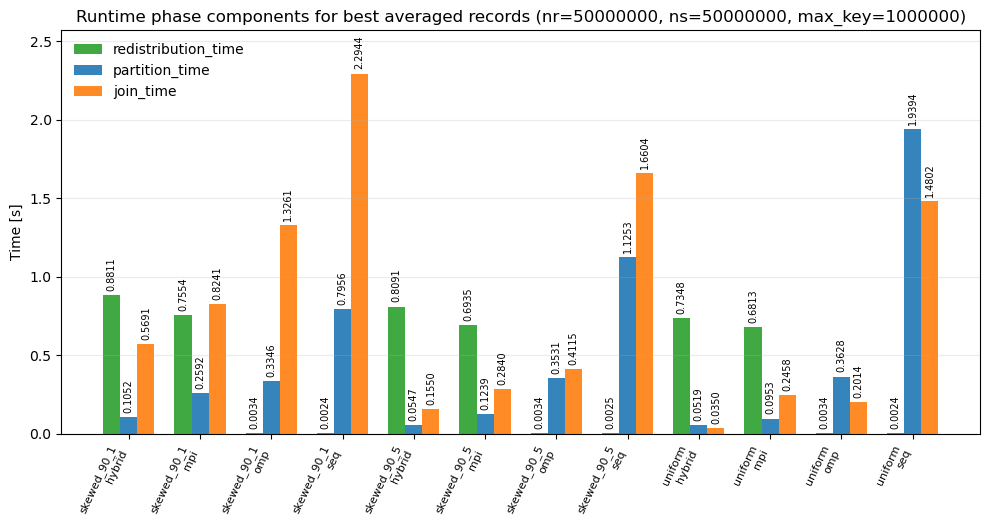

In [216]:
phase_required = set(problem_columns + ["dataset_type", "exec_type", "partition_time", "join_time"])
if phase_required.issubset(selected_best_df.columns):
    phase_df = selected_best_df.dropna(subset=["partition_time", "join_time"]).copy()
    phase_df["label"] = phase_df["dataset_type"].astype(str) + "\n" + phase_df["exec_type"].astype(str)

    component_required = phase_required | {"redistribution_time"}
    if component_required.issubset(selected_best_df.columns):
        component_df = selected_best_df.dropna(subset=["partition_time", "join_time", "redistribution_time"]).copy()
        component_df["label"] = component_df["dataset_type"].astype(str) + "\n" + component_df["exec_type"].astype(str)
        component_specs = [
            ("redistribution_time", "redistribution_time", "tab:green"),
            ("partition_time", "partition_time", "tab:blue"),
            ("join_time", "join_time", "tab:orange"),
        ]

        for problem_key, subdf in component_df.groupby(problem_columns, dropna=False):
            if not isinstance(problem_key, tuple):
                problem_key = (problem_key,)
            subdf = subdf.sort_values(["dataset_type", "exec_type"])
            x_positions = np.arange(len(subdf))
            bar_width = 0.24

            fig, ax = plt.subplots(figsize=(max(10.0, 0.7 * len(subdf)), 5.4))
            for idx, (col, label, color) in enumerate(component_specs):
                offsets = x_positions + (idx - (len(component_specs) - 1) / 2.0) * bar_width
                bars = ax.bar(offsets, subdf[col], width=bar_width, label=label, color=color, alpha=0.9)
                ax.bar_label(
                    bars,
                    labels=[f"{value:.4f}" if np.isfinite(value) else "" for value in subdf[col]],
                    padding=3,
                    fontsize=7,
                    rotation=90,
                )

            ax.set_xticks(x_positions)
            ax.set_xticklabels(subdf["label"], rotation=65, ha="right", fontsize=8)
            ax.set_ylabel("Time [s]")
            ax.set_title(f"Runtime phase components for best averaged records ({problem_label(problem_key)})")
            ax.grid(axis="y", alpha=0.25)
            ax.margins(y=0.12)
            ax.legend(frameon=False)
            fig.tight_layout()
            show_and_save(fig, f"selected_best_phase_components_{'_'.join(fmt_num(v) for v in problem_key)}")
    else:
        print(f"Skipping phase components: missing {sorted(component_required - set(selected_best_df.columns))}")
else:
    print(f"Skipping phase breakdown: missing {sorted(phase_required - set(selected_best_df.columns))}")


# Skew Impact

[saved] img/007_selected_best_skew_penalty_vs_uniform_50000000_50000000_1000000.png


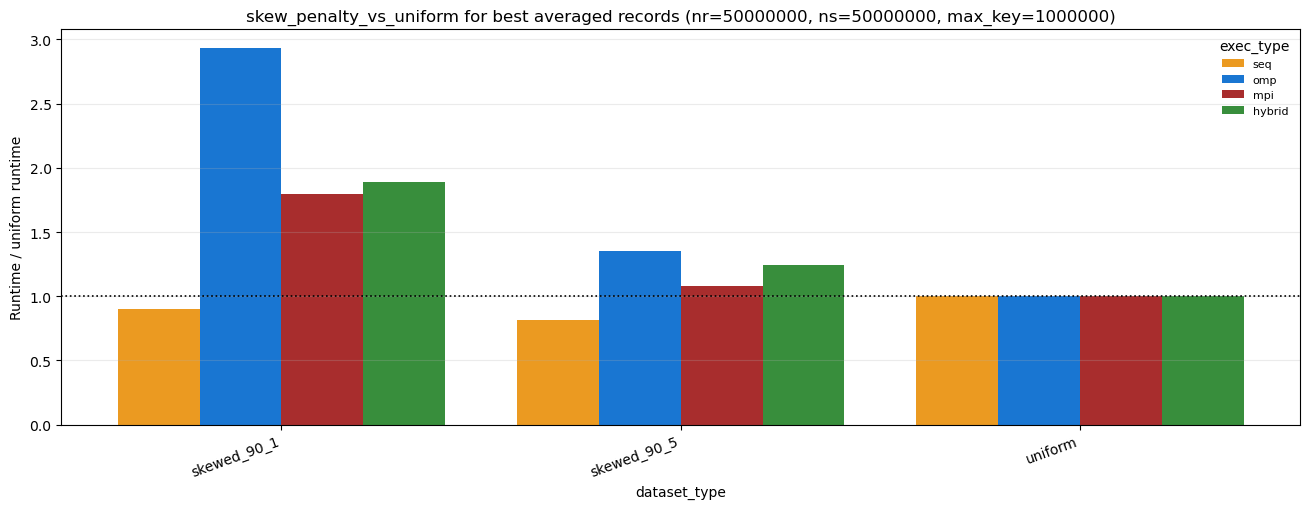

,nr,ns,max_key,dataset_type,exec_type,tot_sec,uniform_tot_sec,skew_penalty_vs_uniform
0,50000000,50000000,1000000,skewed_90_1,hybrid,1.555474,0.821780,1.892812
4,50000000,50000000,1000000,skewed_90_5,hybrid,1.018777,0.821780,1.239720
8,50000000,50000000,1000000,uniform,hybrid,0.821780,0.821780,1.000000
1,50000000,50000000,1000000,skewed_90_1,mpi,1.838680,1.022461,1.798289
5,50000000,50000000,1000000,skewed_90_5,mpi,1.101309,1.022461,1.077116
9,50000000,50000000,1000000,uniform,mpi,1.022461,1.022461,1.000000
2,50000000,50000000,1000000,skewed_90_1,omp,1.664108,0.567521,2.932240
6,50000000,50000000,1000000,skewed_90_5,omp,0.768023,0.567521,1.353294
10,50000000,50000000,1000000,uniform,omp,0.567521,0.567521,1.000000
3,50000000,50000000,1000000,skewed_90_1,seq,3.092431,3.422029,0.903683


In [217]:
skew_key_columns = problem_columns + ["exec_type"]
uniform_rows = selected_best_df[selected_best_df["dataset_type"] == "uniform"][skew_key_columns + ["tot_sec"]]

if uniform_rows.empty:
    print("[warning] No uniform selected records available; skipping skew impact comparison")
    skew_impact_df = pd.DataFrame()
else:
    uniform_rows = uniform_rows.rename(columns={"tot_sec": "uniform_tot_sec"})
    skew_impact_df = selected_best_df.merge(uniform_rows, on=skew_key_columns, how="left")
    skew_impact_df["skew_penalty_vs_uniform"] = skew_impact_df["tot_sec"] / skew_impact_df["uniform_tot_sec"].where(skew_impact_df["uniform_tot_sec"] > 0)
    plot_selected_metric(skew_impact_df, "skew_penalty_vs_uniform", "Runtime / uniform runtime", "skew_penalty_vs_uniform", hline=1.0)

if not skew_impact_df.empty:
    display(skew_impact_df[[col for col in problem_columns + ["dataset_type", "exec_type", "tot_sec", "uniform_tot_sec", "skew_penalty_vs_uniform"] if col in skew_impact_df.columns]].sort_values(problem_columns + ["exec_type", "dataset_type"]))


# Scaling Data Helpers

In [218]:

def existing_paths(paths):
    return [path for path in paths if path.exists()]


def has_valid_numeric_column(frame, column):
    return column in frame.columns and pd.to_numeric(frame[column], errors="coerce").notna().any()


def infer_exec_type_from_frame(frame, fallback):
    has_partition_threads = has_valid_numeric_column(frame, "partition_threads") or has_valid_numeric_column(frame, "join_threads")
    has_mpi_columns = any(has_valid_numeric_column(frame, col) for col in ["mpi_processes", "mpi_active_ranks", "mpi_world_size"])
    uses_multiple_mpi_ranks = False
    for col in ["mpi_processes", "mpi_active_ranks", "mpi_world_size"]:
        if col in frame.columns:
            values = pd.to_numeric(frame[col], errors="coerce")
            if values.max(skipna=True) > 1:
                uses_multiple_mpi_ranks = True
                break

    if has_partition_threads and uses_multiple_mpi_ranks:
        return "hybrid"
    if has_partition_threads:
        return "omp"
    if has_mpi_columns:
        return "mpi"
    return fallback


def load_named_csv_sources(source_specs):
    frames = []
    loaded = []
    missing = []
    for spec in source_specs:
        paths = existing_paths(spec["paths"])
        if not paths:
            missing.append(spec["name"])
            continue
        csv_path = paths[0]
        frame = normalize_frame(pd.read_csv(csv_path))
        frame["source"] = spec["name"]
        if "exec_type" not in frame.columns or frame["exec_type"].isna().all():
            fallback_exec_type = csv_path.stem.replace("hashjoin_", "", 1)
            requested_exec_type = spec.get("exec_type")
            if requested_exec_type == "auto":
                frame["exec_type"] = infer_exec_type_from_frame(frame, fallback_exec_type)
            else:
                frame["exec_type"] = requested_exec_type or fallback_exec_type
        if "dataset_type" not in frame.columns:
            frame["dataset_type"] = spec.get("dataset_type", "uniform")
        frames.append(frame)
        loaded.append((spec["name"], csv_path))

    if loaded:
        print("Loaded scaling sources:")
        for name, csv_path in loaded:
            print(f"  - {name}: {csv_path}")
    if missing:
        print(f"[info] Missing scaling sources: {missing}")

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True, sort=False)


def average_scaling_df(raw_scaling_df, extra_group_columns):
    if raw_scaling_df.empty:
        return raw_scaling_df

    group_columns = [col for col in extra_group_columns if col in raw_scaling_df.columns]
    avg_columns = [
        col for col in raw_scaling_df.columns
        if col not in group_columns and pd.api.types.is_numeric_dtype(raw_scaling_df[col])
    ]
    return (
        raw_scaling_df.groupby(group_columns, as_index=False, dropna=False)
        .agg(**{col: (col, "mean") for col in avg_columns}, n_runs=("tot_sec", "size"))
        .sort_values(group_columns)
        .reset_index(drop=True)
    )


def add_scaling_axis_columns(scaling_df):
    scaling_df = scaling_df.copy()
    for col in ["partition_threads", "join_threads", "mpi_processes", "mpi_active_ranks", "mpi_world_size"]:
        if col in scaling_df.columns:
            scaling_df[col] = pd.to_numeric(scaling_df[col], errors="coerce")

    scaling_df["scaling_units"] = np.nan
    scaling_df["scaling_axis"] = "unknown"

    if "partition_threads" in scaling_df.columns and "join_threads" in scaling_df.columns:
        mask = scaling_df["partition_threads"].notna() & scaling_df["join_threads"].notna() & (scaling_df["partition_threads"] == scaling_df["join_threads"])
        scaling_df.loc[mask, "scaling_units"] = scaling_df.loc[mask, "partition_threads"]
        scaling_df.loc[mask, "scaling_axis"] = "omp_threads"
    if "partition_threads" in scaling_df.columns:
        mask = scaling_df["scaling_units"].isna() & scaling_df["partition_threads"].notna()
        scaling_df.loc[mask, "scaling_units"] = scaling_df.loc[mask, "partition_threads"]
        scaling_df.loc[mask, "scaling_axis"] = "partition_threads"
    if "join_threads" in scaling_df.columns:
        mask = scaling_df["scaling_units"].isna() & scaling_df["join_threads"].notna()
        scaling_df.loc[mask, "scaling_units"] = scaling_df.loc[mask, "join_threads"]
        scaling_df.loc[mask, "scaling_axis"] = "join_threads"

    for col, axis_name in [
        ("mpi_processes", "mpi_processes"),
        ("mpi_active_ranks", "mpi_active_ranks"),
        ("mpi_world_size", "mpi_world_size"),
    ]:
        if col in scaling_df.columns:
            mask = scaling_df["scaling_units"].isna() & scaling_df[col].notna()
            scaling_df.loc[mask, "scaling_units"] = scaling_df.loc[mask, col]
            scaling_df.loc[mask, "scaling_axis"] = axis_name

    return scaling_df


def scaling_axis_label(plot_df, units_col="scaling_units"):
    if plot_df is None or plot_df.empty or "scaling_axis" not in plot_df.columns:
        return "Scaling units"
    axes = ordered_values(plot_df["scaling_axis"])
    if len(axes) == 1:
        return {
            "omp_threads": "Threads (partition = join)",
            "partition_threads": "Partition threads",
            "join_threads": "Join threads",
            "mpi_processes": "MPI processes",
            "mpi_active_ranks": "MPI active ranks",
            "mpi_world_size": "MPI world size",
        }.get(axes[0], "Scaling units")
    return "Scaling units"


def prepare_scaling_plot_df(raw_scaling_df, scaling_kind):
    if raw_scaling_df.empty:
        return pd.DataFrame(), None

    scaling_df = add_scaling_axis_columns(raw_scaling_df)
    if scaling_df.empty:
        print(f"[warning] No {scaling_kind} rows after scaling-axis detection")
        return pd.DataFrame(), "scaling_units"

    scaling_df["perf"] = np.nan
    if "total_throughput" in scaling_df.columns:
        scaling_df["perf"] = scaling_df["total_throughput"]
    if "tot_sec" in scaling_df.columns:
        scaling_df["perf"] = scaling_df["perf"].fillna(1.0 / scaling_df["tot_sec"].where(scaling_df["tot_sec"] > 0))

    scaling_df = scaling_df.dropna(subset=["scaling_units", "perf"]).copy()
    if scaling_df.empty:
        print(f"[warning] No valid {scaling_kind} scaling performance rows")
        return pd.DataFrame(), "scaling_units"

    group_columns = [
        "source", "exec_type", "dataset_type", "nr", "ns", "max_key", "scaling_axis", "scaling_units",
        "mpi_nodes", "mpi_processes", "mpi_world_size", "mpi_active_ranks", "mpi_partition_strategy",
    ]
    scaling_avg_df = average_scaling_df(scaling_df, group_columns)
    return scaling_avg_df, "scaling_units"


def plot_scaling_bars(plot_df, threads_col, metric_col, ylabel, title, filename_prefix, group_by_n=True, series_columns=None, series_labeler=None, series_colorer=None):
    if plot_df.empty:
        print(f"Skipping {title}: no rows")
        return

    group_columns = ["nr", "ns", "max_key"] if group_by_n else []
    grouped = plot_df.groupby(group_columns, dropna=False) if group_columns else [((), plot_df)]

    for problem_key, subdf in grouped:
        if not isinstance(problem_key, tuple):
            problem_key = (problem_key,)
        thread_values = ordered_values(subdf[threads_col])
        if series_columns is None:
            series_columns = ["source", "exec_type", "dataset_type"]
        series_columns = [col for col in series_columns if col in subdf.columns]
        series_df = subdf[series_columns].drop_duplicates().sort_values(series_columns)
        series_records = series_df.to_dict("records")
        if not thread_values or not series_records:
            continue

        x_positions = np.arange(len(thread_values))
        bar_width = 0.82 / max(len(series_records), 1)
        fig_width = min(14.0, max(9.5, 0.45 * len(thread_values) * len(series_records)))
        fig, ax = plt.subplots(figsize=(fig_width, 5.4))

        for idx, series in enumerate(series_records):
            mask = np.ones(len(subdf), dtype=bool)
            for col, value in series.items():
                mask &= subdf[col].eq(value).to_numpy()
            series_sub = subdf[mask]
            values = series_sub.set_index(threads_col)[metric_col].to_dict()
            heights = [float(values.get(thread, np.nan)) for thread in thread_values]
            offsets = x_positions + (idx - (len(series_records) - 1) / 2.0) * bar_width
            if series_labeler is not None:
                label = series_labeler(series)
            else:
                label_parts = []
                for col in series_columns:
                    value = series[col]
                    if col in {"nr", "ns", "max_key"}:
                        label_parts.append(f"{col}={fmt_num(value)}")
                    else:
                        label_parts.append(str(value))
                label = " / ".join(label_parts)
            if series_colorer is not None:
                color = series_colorer(series)
            else:
                color = DATASET_TYPE_COLORS.get(series.get("dataset_type"), color_map.get(series.get("exec_type"), None))
            ax.bar(offsets, heights, width=bar_width, label=label, color=color, alpha=0.9)

        ax.axhline(1.0, color="black", linestyle=":", linewidth=1.2)
        ax.set_xticks(x_positions)
        ax.set_xticklabels([fmt_num(t) for t in thread_values])
        ax.set_xlabel(scaling_axis_label(subdf, threads_col))
        ax.set_ylabel(ylabel)
        title_suffix = f" ({problem_label(problem_key)})" if group_columns else ""
        ax.set_title(title + title_suffix)
        ax.grid(axis="y", alpha=0.25)
        ax.legend(fontsize=7, frameon=False)
        fig.tight_layout()
        suffix = "_".join(fmt_num(v) for v in problem_key) if group_columns else "all"
        show_and_save(fig, f"{filename_prefix}_{suffix}")


# Interpretation Tables

In [219]:
interpretation_columns = [
    col for col in problem_columns + [
        "dataset_type", "exec_type", "tot_sec", "partition_time", "join_time",
        "redistribution_time", "redistribution_throughput",
        "total_throughput", "partition_threads", "join_threads", "partition_schedule",
        "join_schedule", "partition_block_size", "partition_task_grain",
        "join_task_grain", "offset_task_grain",
        "mpi_nodes", "mpi_processes", "mpi_world_size", "mpi_active_ranks",
        "mpi_partition_strategy",
    ] if col in selected_best_df.columns
]

best_by_dataset = selected_best_df.sort_values(problem_columns + ["dataset_type", "tot_sec"]).groupby(problem_columns + ["dataset_type"], dropna=False).head(1)
print("Fastest implementation per dataset_type:")
display(best_by_dataset[interpretation_columns].reset_index(drop=True))

if not speedup_selected_df.empty and "speedup_vs_seq" in speedup_selected_df.columns:
    print("Best selected records ranked by speedup vs sequential baseline:")
    display(speedup_selected_df.sort_values("speedup_vs_seq", ascending=False)[[col for col in interpretation_columns + ["speedup_vs_seq"] if col in speedup_selected_df.columns]].reset_index(drop=True))


Fastest implementation per dataset_type:


,nr,ns,max_key,dataset_type,exec_type,tot_sec,partition_time,join_time,redistribution_time,redistribution_throughput,...,join_schedule,partition_block_size,partition_task_grain,join_task_grain,offset_task_grain,mpi_nodes,mpi_processes,mpi_world_size,mpi_active_ranks,mpi_partition_strategy
0,50000000,50000000,1000000,skewed_90_1,hybrid,1.555474,0.105230,0.569112,0.881133,1.134902e+08,...,guided,32768.0,NaN,NaN,NaN,8,8,8.0,8.0,cyclic
1,50000000,50000000,1000000,skewed_90_5,omp,0.768023,0.353084,0.411525,0.003414,2.928944e+10,...,guided,32768.0,NaN,NaN,NaN,1,1,NaN,NaN,block
2,50000000,50000000,1000000,uniform,omp,0.567521,0.362799,0.201371,0.003351,2.983828e+10,...,guided,32768.0,NaN,NaN,NaN,1,1,NaN,NaN,block


Best selected records ranked by speedup vs sequential baseline:


,nr,ns,max_key,dataset_type,exec_type,tot_sec,partition_time,join_time,redistribution_time,redistribution_throughput,...,partition_block_size,partition_task_grain,join_task_grain,offset_task_grain,mpi_nodes,mpi_processes,mpi_world_size,mpi_active_ranks,mpi_partition_strategy,speedup_vs_seq
0,50000000,50000000,1000000,uniform,omp,0.567521,0.362799,0.201371,0.003351,2.983828e+10,...,32768.0,NaN,NaN,NaN,1,1,NaN,NaN,block,6.029782
1,50000000,50000000,1000000,uniform,hybrid,0.821780,0.051907,0.035048,0.734825,1.360867e+08,...,32768.0,NaN,NaN,NaN,8,8,8.0,8.0,cyclic,4.164168
2,50000000,50000000,1000000,skewed_90_5,omp,0.768023,0.353084,0.411525,0.003414,2.928944e+10,...,32768.0,NaN,NaN,NaN,1,1,NaN,NaN,block,3.630469
3,50000000,50000000,1000000,uniform,mpi,1.022461,0.095336,0.245807,0.681318,1.467744e+08,...,NaN,NaN,NaN,NaN,8,8,8.0,8.0,cyclic,3.346856
4,50000000,50000000,1000000,skewed_90_5,hybrid,1.018777,0.054706,0.154998,0.809073,1.235982e+08,...,32768.0,NaN,NaN,NaN,8,8,8.0,8.0,cyclic,2.736892
5,50000000,50000000,1000000,skewed_90_5,mpi,1.101309,0.123905,0.283952,0.693451,1.442063e+08,...,NaN,NaN,NaN,NaN,1,8,8.0,8.0,cyclic,2.531791
6,50000000,50000000,1000000,skewed_90_1,hybrid,1.555474,0.105230,0.569112,0.881133,1.134902e+08,...,32768.0,NaN,NaN,NaN,8,8,8.0,8.0,cyclic,1.988095
7,50000000,50000000,1000000,skewed_90_1,omp,1.664108,0.334625,1.326118,0.003365,2.971592e+10,...,32768.0,NaN,NaN,NaN,1,1,NaN,NaN,block,1.858311
8,50000000,50000000,1000000,skewed_90_1,mpi,1.838680,0.259173,0.824089,0.755418,1.323771e+08,...,NaN,NaN,NaN,NaN,1,8,8.0,8.0,cyclic,1.681876
9,50000000,50000000,1000000,skewed_90_1,seq,3.092431,0.795621,2.294389,0.002422,4.129501e+10,...,32768.0,1.0,1.0,1.0,1,1,NaN,NaN,block,1.000000


# Strong Scalability


[saved] img/008_strong_scalability_speedup_by_dataset.png


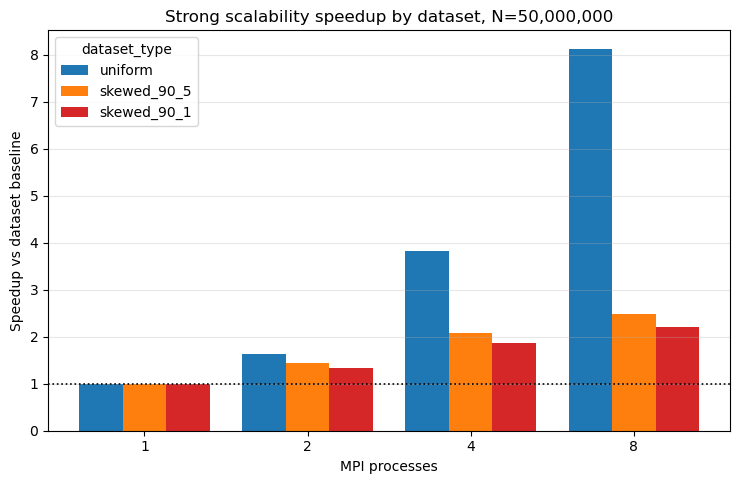

[saved] img/009_strong_scalability_efficiency_by_dataset.png


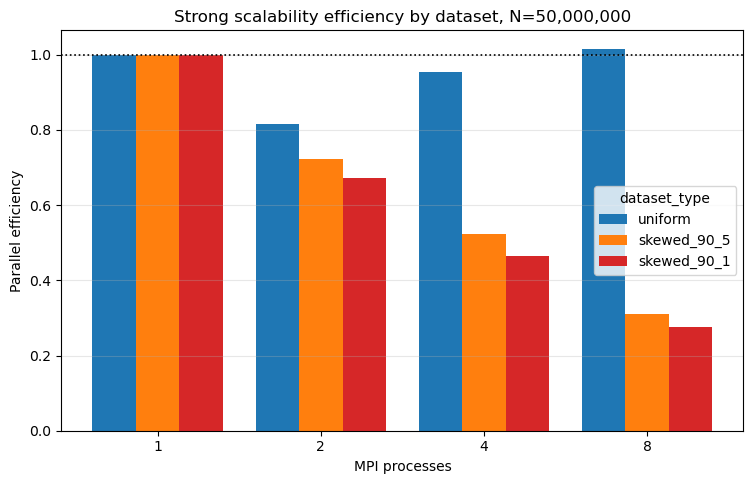

,dataset_type,nr,ns,max_key,scaling_axis,scaling_units,mpi_nodes,mpi_processes,mpi_world_size,mpi_active_ranks,...,time_sec,total_throughput,verified,tot_sec,perf,n_runs,baseline_units,baseline_time,speedup,parallel_efficiency
0,skewed_90_1,50000000,50000000,1000000,mpi_processes,1.0,1,1,1,1,...,9.741883,1.026525e+07,0.0,9.741883,1.026525e+07,5,1.0,9.741883,1.000000,1.000000
1,skewed_90_1,50000000,50000000,1000000,mpi_processes,2.0,2,2,2,2,...,7.244410,1.380451e+07,0.0,7.244410,1.380451e+07,5,1.0,9.741883,1.344745,0.672372
2,skewed_90_1,50000000,50000000,1000000,mpi_processes,4.0,4,4,4,4,...,5.241274,1.907951e+07,0.0,5.241274,1.907951e+07,5,1.0,9.741883,1.858686,0.464672
3,skewed_90_1,50000000,50000000,1000000,mpi_processes,8.0,8,8,8,8,...,4.431784,2.256453e+07,0.0,4.431784,2.256453e+07,5,1.0,9.741883,2.198185,0.274773
4,skewed_90_5,50000000,50000000,1000000,mpi_processes,1.0,1,1,1,1,...,9.461907,1.056892e+07,0.0,9.461907,1.056892e+07,5,1.0,9.461907,1.000000,1.000000
5,skewed_90_5,50000000,50000000,1000000,mpi_processes,2.0,2,2,2,2,...,6.550329,1.526647e+07,0.0,6.550329,1.526647e+07,5,1.0,9.461907,1.444493,0.722247
6,skewed_90_5,50000000,50000000,1000000,mpi_processes,4.0,4,4,4,4,...,4.531974,2.206624e+07,0.0,4.531974,2.206624e+07,5,1.0,9.461907,2.087811,0.521953
7,skewed_90_5,50000000,50000000,1000000,mpi_processes,8.0,8,8,8,8,...,3.794747,2.635328e+07,0.0,3.794747,2.635328e+07,5,1.0,9.461907,2.493422,0.311678
8,uniform,50000000,50000000,1000000,mpi_processes,1.0,1,1,1,1,...,10.162241,9.843691e+06,0.0,10.162241,9.843691e+06,5,1.0,10.162241,1.000000,1.000000
9,uniform,50000000,50000000,1000000,mpi_processes,2.0,2,2,2,2,...,6.219513,1.681416e+07,0.0,6.219513,1.681416e+07,5,1.0,10.162241,1.633929,0.816964


In [220]:

strong_path = RESULTS_DIR / "strong_scaling.csv"
if not strong_path.exists():
    raise FileNotFoundError(f"Run the scaling benchmark first; missing {strong_path}")

strong_scale_df = normalize_frame(pd.read_csv(strong_path))
strong_scale_df, strong_units_col = prepare_scaling_plot_df(strong_scale_df, "strong")
if strong_scale_df.empty:
    raise ValueError("No valid strong-scaling rows available")

strong_key_cols = [col for col in ["dataset_type", "nr", "ns", "max_key", "scaling_axis"] if col in strong_scale_df.columns]
baseline = (
    strong_scale_df.sort_values(strong_units_col)
    .groupby(strong_key_cols, as_index=False, dropna=False)
    .first()[strong_key_cols + [strong_units_col, "time_sec"]]
    .rename(columns={strong_units_col: "baseline_units", "time_sec": "baseline_time"})
)
strong_scale_df = strong_scale_df.merge(baseline, on=strong_key_cols, how="left")
strong_scale_df = strong_scale_df[strong_scale_df["baseline_time"] > 0].copy()
strong_scale_df["speedup"] = strong_scale_df["baseline_time"] / strong_scale_df["time_sec"]
strong_scale_df["parallel_efficiency"] = strong_scale_df["speedup"] / (strong_scale_df[strong_units_col] / strong_scale_df["baseline_units"])

sort_cols = [col for col in ["dataset_type", "scaling_axis", strong_units_col] if col in strong_scale_df.columns]
strong_scale_df = strong_scale_df.sort_values(sort_cols).reset_index(drop=True)

dataset_order = [name for name in DATASET_TYPE_ORDER if name in set(strong_scale_df["dataset_type"])]
dataset_order += [name for name in ordered_values(strong_scale_df["dataset_type"]) if name not in dataset_order]
dataset_colors = DATASET_TYPE_COLORS
unit_values = ordered_values(strong_scale_df[strong_units_col], preferred=[1, 2, 4, 8, 16, 32, 64])
unit_positions = np.arange(len(unit_values))
unit_labels = [str(int(t)) for t in unit_values]
bar_width = 0.8 / max(len(dataset_order), 1)

fixed_n = int(strong_scale_df["nr"].dropna().max()) if "nr" in strong_scale_df.columns and strong_scale_df["nr"].notna().any() else None
for metric_col, ylabel, title, filename in [
    ("speedup", "Speedup vs dataset baseline", "Strong scalability speedup by dataset", "strong_scalability_speedup_by_dataset"),
    ("parallel_efficiency", "Parallel efficiency", "Strong scalability efficiency by dataset", "strong_scalability_efficiency_by_dataset"),
]:
    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    for idx, dataset_type in enumerate(dataset_order):
        sub = strong_scale_df[strong_scale_df["dataset_type"] == dataset_type].set_index(strong_units_col)[metric_col].to_dict()
        heights = [float(sub.get(unit, np.nan)) for unit in unit_values]
        offsets = [
            x + (idx - (len(dataset_order) - 1) / 2.0) * bar_width
            for x in unit_positions
        ]
        ax.bar(
            offsets,
            heights,
            width=bar_width,
            label=dataset_type,
            color=dataset_colors.get(dataset_type),
        )
    ax.axhline(1.0, color="black", linestyle=":", linewidth=1.2)
    ax.set_xticks(unit_positions)
    ax.set_xticklabels(unit_labels)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(scaling_axis_label(strong_scale_df, strong_units_col))
    ax.set_ylabel(ylabel)
    if fixed_n is not None:
        ax.set_title(f"{title}, N={fixed_n:,}")
    else:
        ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="dataset_type")
    show_and_save(fig, filename)

display(strong_scale_df.reset_index(drop=True))


# Weak Scalability


[saved] img/010_weak_scalability_scaled_speedup_by_dataset.png


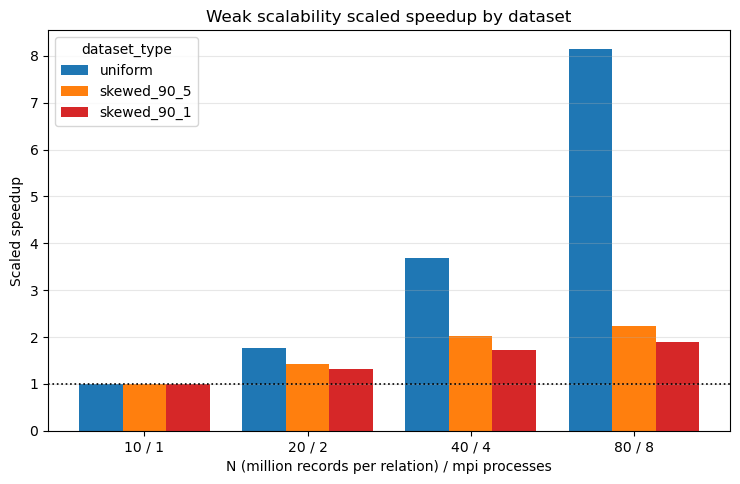

[saved] img/011_weak_scalability_efficiency_by_dataset.png


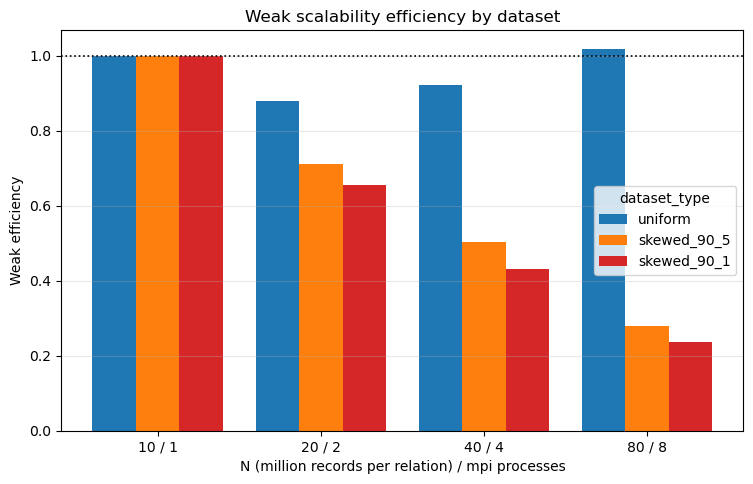

,dataset_type,nr,ns,max_key,scaling_axis,scaling_units,mpi_nodes,mpi_processes,mpi_world_size,mpi_active_ranks,...,time_sec,total_throughput,verified,tot_sec,perf,n_runs,baseline_units,baseline_time,scaled_speedup,weak_efficiency
0,skewed_90_1,10000000,10000000,1000000,mpi_processes,1.0,1,1,1,1,...,1.841877,1.085905e+07,0.0,1.841877,1.085905e+07,5,1.0,1.841877,1.000000,1.000000
1,skewed_90_1,20000000,20000000,1000000,mpi_processes,2.0,2,2,2,2,...,2.805737,1.425797e+07,0.0,2.805737,1.425797e+07,5,1.0,1.841877,1.312936,0.656468
2,skewed_90_1,40000000,40000000,1000000,mpi_processes,4.0,4,4,4,4,...,4.258477,1.878670e+07,0.0,4.258477,1.878670e+07,5,1.0,1.841877,1.730081,0.432520
3,skewed_90_1,80000000,80000000,1000000,mpi_processes,8.0,8,8,8,8,...,7.824046,2.045044e+07,0.0,7.824046,2.045044e+07,5,1.0,1.841877,1.883299,0.235412
4,skewed_90_5,10000000,10000000,1000000,mpi_processes,1.0,1,1,1,1,...,1.885322,1.060895e+07,0.0,1.885322,1.060895e+07,5,1.0,1.885322,1.000000,1.000000
5,skewed_90_5,20000000,20000000,1000000,mpi_processes,2.0,2,2,2,2,...,2.648008,1.510598e+07,0.0,2.648008,1.510598e+07,5,1.0,1.885322,1.423955,0.711977
6,skewed_90_5,40000000,40000000,1000000,mpi_processes,4.0,4,4,4,4,...,3.738778,2.139869e+07,0.0,3.738778,2.139869e+07,5,1.0,1.885322,2.017046,0.504262
7,skewed_90_5,80000000,80000000,1000000,mpi_processes,8.0,8,8,8,8,...,6.775802,2.361483e+07,0.0,6.775802,2.361483e+07,5,1.0,1.885322,2.225947,0.278243
8,uniform,10000000,10000000,1000000,mpi_processes,1.0,1,1,1,1,...,1.943295,1.029182e+07,0.0,1.943295,1.029182e+07,5,1.0,1.943295,1.000000,1.000000
9,uniform,20000000,20000000,1000000,mpi_processes,2.0,2,2,2,2,...,2.209289,1.811697e+07,0.0,2.209289,1.811697e+07,5,1.0,1.943295,1.759203,0.879602


In [221]:

weak_path = RESULTS_DIR / "weak_scaling.csv"
if not weak_path.exists():
    raise FileNotFoundError(f"Run the scaling benchmark first; missing {weak_path}")

weak_scale_df = normalize_frame(pd.read_csv(weak_path))
weak_scale_df, weak_units_col = prepare_scaling_plot_df(weak_scale_df, "weak")
if weak_scale_df.empty:
    raise ValueError("No valid weak-scaling rows available")

weak_key_cols = [col for col in ["dataset_type", "max_key", "scaling_axis"] if col in weak_scale_df.columns]
baseline = (
    weak_scale_df.sort_values(weak_key_cols + [weak_units_col, "nr"])
    .groupby(weak_key_cols, as_index=False, dropna=False)
    .first()[weak_key_cols + [weak_units_col, "time_sec"]]
    .rename(columns={weak_units_col: "baseline_units", "time_sec": "baseline_time"})
)
weak_scale_df = weak_scale_df.merge(baseline, on=weak_key_cols, how="left")
weak_scale_df = weak_scale_df[weak_scale_df["baseline_time"] > 0].copy()

# With weak scaling, work grows with the scaling unit count. Ideal behavior keeps time constant.
weak_scale_df["scaled_speedup"] = (weak_scale_df[weak_units_col] / weak_scale_df["baseline_units"]) * (weak_scale_df["baseline_time"] / weak_scale_df["time_sec"])
weak_scale_df["weak_efficiency"] = weak_scale_df["baseline_time"] / weak_scale_df["time_sec"]

sort_cols = [col for col in ["dataset_type", "scaling_axis", weak_units_col, "nr"] if col in weak_scale_df.columns]
weak_scale_df = weak_scale_df.sort_values(sort_cols).reset_index(drop=True)

dataset_order = [name for name in DATASET_TYPE_ORDER if name in set(weak_scale_df["dataset_type"])]
dataset_order += [name for name in ordered_values(weak_scale_df["dataset_type"]) if name not in dataset_order]
dataset_colors = DATASET_TYPE_COLORS
case_df = (
    weak_scale_df[["nr", weak_units_col]]
    .drop_duplicates()
    .sort_values([weak_units_col, "nr"])
    .reset_index(drop=True)
)
case_keys = list(case_df.itertuples(index=False, name=None))
case_positions = np.arange(len(case_keys))
case_labels = [f"{int(n / 1_000_000)} / {int(t)}" for n, t in case_keys]
bar_width = 0.8 / max(len(dataset_order), 1)

for metric_col, ylabel, title, filename in [
    ("scaled_speedup", "Scaled speedup", "Weak scalability scaled speedup by dataset", "weak_scalability_scaled_speedup_by_dataset"),
    ("weak_efficiency", "Weak efficiency", "Weak scalability efficiency by dataset", "weak_scalability_efficiency_by_dataset"),
]:
    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    for idx, dataset_type in enumerate(dataset_order):
        sub = weak_scale_df[weak_scale_df["dataset_type"] == dataset_type].set_index(["nr", weak_units_col])[metric_col].to_dict()
        heights = [float(sub.get(key, np.nan)) for key in case_keys]
        offsets = [
            x + (idx - (len(dataset_order) - 1) / 2.0) * bar_width
            for x in case_positions
        ]
        ax.bar(
            offsets,
            heights,
            width=bar_width,
            label=dataset_type,
            color=dataset_colors.get(dataset_type),
        )
    ax.axhline(1.0, color="black", linestyle=":", linewidth=1.2)
    ax.set_xticks(case_positions)
    ax.set_xticklabels(case_labels)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(f"N (million records per relation) / {scaling_axis_label(weak_scale_df, weak_units_col).lower()}")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(title="dataset_type")
    show_and_save(fig, filename)

display(weak_scale_df.reset_index(drop=True))
